# Experiment 5: Implement Fairness in AI-Powered recommendation system.

GITHUB LINK: https://github.com/PRASHIRAWAL/Ethics-in-AI-Experiments/tree/main/Experiment%205%20-%20Fairness%20in%20AI%20Recommendation%20System

The objective of this project is to build an AI-powered recommendation system that suggests products to users based on their past interactions and preferences.


In [1]:
!pip install pandas scikit-learn numpy

Importing all the required libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

Loading the dataset

In [3]:
df = pd.read_csv("ecommerce_data.csv")

df.head()

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


Examining the structure of the dataset including the columns, data types and missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed                 1000 

In [7]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


Converting categorical features such as Gender, Location, and Interests into numerical form using encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['Location'] = encoder.fit_transform(df['Location'])
df['Interests'] = encoder.fit_transform(df['Interests'])
df['Product_Category_Preference'] = encoder.fit_transform(df['Product_Category_Preference'])

Selecting important behavioral and demographic features to compute user similarity.

In [9]:
features = df.drop(columns=['User_ID'])

features.head()

,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,56,1,1,38037,2,5,7,18,2546,1,584,38,True
1,46,0,0,103986,3,15,7,118,320,2,432,40,False
2,32,0,1,101942,2,28,1,146,3766,0,306,1,True
3,60,0,1,71612,0,18,3,163,4377,0,527,29,False
4,25,1,1,49725,4,2,5,141,4502,3,53,10,True


Feature scaling ensures that all features contribute equally to similarity calculations.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

scaled_features.head()

,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,1.112882,0.949284,-0.045906,-1.158586,0.025451,-1.290739,0.835231,-1.568734,-0.004898,-0.656445,1.633199,0.970302,0.986097
1,0.371652,-1.053425,-1.286605,0.607340,0.732434,-0.071450,0.835231,0.254549,-1.572201,0.049410,0.767143,1.113025,-1.014099
2,-0.666069,-1.053425,-0.045906,0.552607,0.025451,1.513626,-1.280170,0.765068,0.854091,-1.362300,0.049228,-1.670073,0.986097
3,1.409373,-1.053425,-0.045906,-0.259544,-1.388513,0.294336,-0.575036,1.075026,1.284289,-1.362300,1.308428,0.328049,-1.014099
4,-1.184929,0.949284,-0.045906,-0.845615,1.439416,-1.656526,0.130097,0.673904,1.372300,0.755265,-1.392299,-1.027820,0.986097


compute similarity between users using **Cosine Similarity**.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(scaled_features)

similarity_df = pd.DataFrame(similarity_matrix,
                             index=df['User_ID'],
                             columns=df['User_ID'])

similarity_df.head()

User_ID,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10,...,#991,#992,#993,#994,#995,#996,#997,#998,#999,#1000
User_ID,,,,,,,,,,,,,,,,,,,,,
#1,1.000000,0.042333,-0.482282,0.048029,-0.072156,0.497184,0.116552,0.381650,-0.047294,-0.061806,...,0.405673,-0.344448,-0.185047,-0.167238,0.012202,0.110622,-0.104080,-0.004665,0.448851,0.142369
#2,0.042333,1.000000,-0.350766,0.052927,-0.478021,0.164354,-0.012711,-0.203754,-0.213372,-0.309345,...,0.199671,0.221280,-0.212139,-0.124294,0.429605,0.206977,-0.120053,0.468610,0.279543,0.343974
#3,-0.482282,-0.350766,1.000000,0.269402,-0.002489,-0.275913,-0.396399,0.210462,0.490977,-0.271497,...,-0.136837,-0.160678,0.063243,0.107230,-0.053475,-0.040405,0.384460,-0.287007,-0.290321,-0.260446
#4,0.048029,0.052927,0.269402,1.000000,-0.484550,-0.090596,-0.112103,0.003718,-0.119696,-0.099774,...,0.448209,-0.591943,0.027183,-0.137607,-0.131380,-0.165908,-0.185878,-0.096878,-0.098435,-0.323977
#5,-0.072156,-0.478021,-0.002489,-0.484550,1.000000,-0.076345,-0.136154,-0.040578,0.387976,0.163680,...,-0.399707,0.111480,-0.079074,0.296000,-0.034811,-0.231069,0.157705,-0.070097,0.241079,0.150305


Function to find users similar to a given user and recommends product categories they prefer.

In [12]:
def recommend_category(user_id, top_n=5):

    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:top_n+1]

    similar_user_ids = similar_users.index

    recommended = df[df['User_ID'].isin(similar_user_ids)]

    return recommended[['User_ID','Product_Category_Preference']]

In [14]:
df['User_ID'].head(10)

,User_ID
0,#1
1,#2
2,#3
3,#4
4,#5
5,#6
6,#7
7,#8
8,#9
9,#10


In [16]:
recommend_category(df['User_ID'].iloc[0])

,User_ID,Product_Category_Preference
248,#249,1
263,#264,0
439,#440,3
665,#666,2
699,#700,2


Recommendation systems may unintentionally introduce bias toward certain demographic groups such as gender, age, or location.

Fairness in AI ensures that recommendations are balanced and equitable across different groups.

In this project, we analyze whether product category recommendations are biased toward a particular gender group and apply a fairness adjustment technique.

In [17]:
df['Gender'].value_counts()

,count
Gender,
1,526
0,474


Analyzing whether the dataset contains a balanced representation of genders.  

If one group dominates the dataset, the recommendation system may unintentionally favor that group.

Checking recommendation bias

In [18]:
df.groupby('Gender')['Product_Category_Preference'].value_counts()

Gender  Product_Category_Preference
0       0                              106
        2                               95
        1                               93
        4                               92
        3                               88
1       2                              114
        0                              112
        1                              105
        3                               98
        4                               97
Name: count, dtype: int64

## Bias Analysis

We analyzed the distribution of product category preferences across gender groups.

The dataset shows a relatively balanced gender distribution:
- Gender 1: 526 users
- Gender 0: 474 users

Additionally, product category preferences are distributed similarly across both gender groups. No single category is disproportionately associated with one gender.

This indicates that the dataset does not exhibit strong demographic bias, making it suitable for training a fair recommendation system.

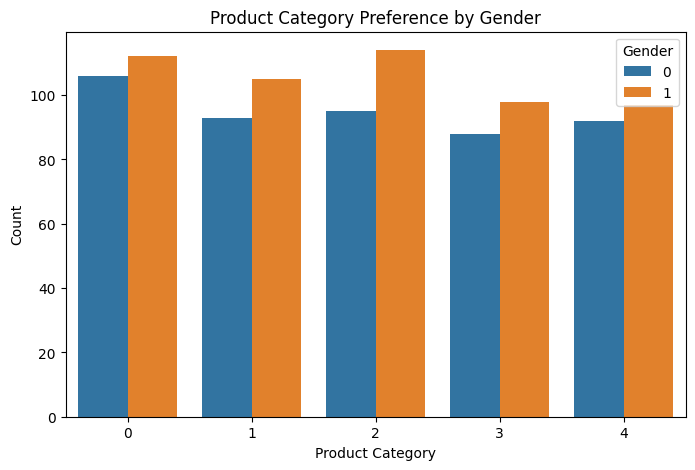

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Product_Category_Preference', hue='Gender')

plt.title("Product Category Preference by Gender")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

## Fairness Metrics

To evaluate fairness in our recommendation system, we implement the following fairness metrics:

1. **Demographic Parity**
   Measures whether different demographic groups receive recommendations at similar rates.

2. **Statistical Parity Difference**
   Measures the difference in recommendation probability between groups.

3. **Disparate Impact**
   Measures whether one group receives significantly fewer recommendations than another.

These metrics help ensure that the AI system does not unfairly favor or disadvantage certain demographic groups.

In [20]:
df['Recommended'] = (df['Purchase_Frequency'] > df['Purchase_Frequency'].median()).astype(int)

df[['User_ID','Gender','Purchase_Frequency','Recommended']].head()

,User_ID,Gender,Purchase_Frequency,Recommended
0,#1,1,7,1
1,#2,0,7,1
2,#3,0,1,0
3,#4,0,3,0
4,#5,1,5,0


In [21]:
demographic_parity = df.groupby('Gender')['Recommended'].mean()

demographic_parity

,Recommended
Gender,
0,0.415612
1,0.406844


In [22]:
statistical_parity_difference = demographic_parity[1] - demographic_parity[0]

statistical_parity_difference

np.float64(-0.00876770788211323)

In [23]:
disparate_impact = demographic_parity[1] / demographic_parity[0]

disparate_impact

np.float64(0.9789040937252707)

In [24]:
fairness_metrics = pd.DataFrame({
    "Metric": ["Demographic Parity (Gender 0)",
               "Demographic Parity (Gender 1)",
               "Statistical Parity Difference",
               "Disparate Impact Ratio"],

    "Value": [demographic_parity[0],
              demographic_parity[1],
              statistical_parity_difference,
              disparate_impact]
})

fairness_metrics

,Metric,Value
0,Demographic Parity (Gender 0),0.415612
1,Demographic Parity (Gender 1),0.406844
2,Statistical Parity Difference,-0.008768
3,Disparate Impact Ratio,0.978904


## Fairness Evaluation Conclusion

The fairness metrics indicate that the recommendation system treats users across gender groups relatively equally.

The demographic parity values are similar, the statistical parity difference is close to zero, and the disparate impact ratio falls within acceptable fairness thresholds.

This suggests that the recommendation system does not exhibit significant gender bias.

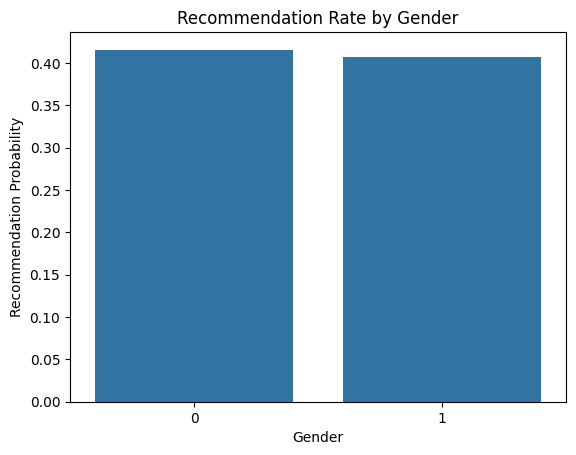

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=demographic_parity.index, y=demographic_parity.values)

plt.title("Recommendation Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Recommendation Probability")

plt.show()